In [1]:
!pip install nltk seaborn

Access is denied.


In [2]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gunti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gunti\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
df = pd.read_csv("fake_or_real_news.csv")

df.head()

,id,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [7]:
df['title_len'] = df['title'].apply(lambda x: len(x.split(' ')))
df.head()

,id,title,text,label,title_len
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,5
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,14
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,9
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,15
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,9


In [8]:
max(df['title_len'])

53

In [9]:
df['content'] = df['title'] + " " + df['text']
df = df[['content','label']]

In [12]:
EDA

NameError: name 'EDA' is not defined

C:\Users\gunti\AppData\Local\Temp\ipykernel_5972\820316339.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['length'] = df['content'].apply(len)


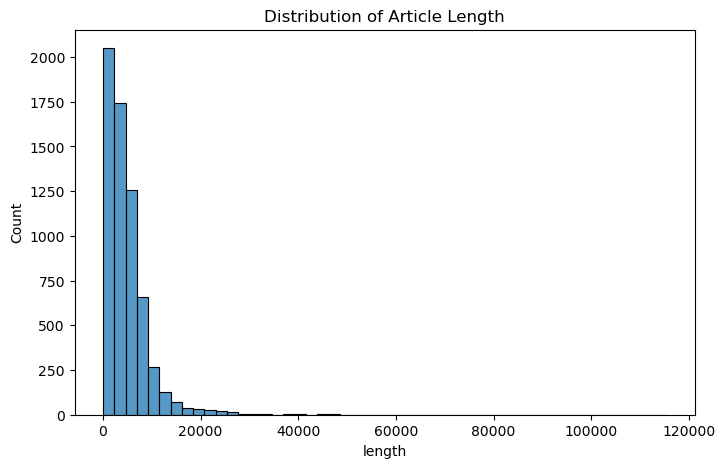

In [10]:
df['length'] = df['content'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df['length'], bins=50)
plt.title("Distribution of Article Length")
plt.show()

In [13]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(f"[{string.punctuation}]", "", text)

    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha()]
    tokens = [w for w in tokens if w not in stop_words]

    return " ".join(tokens)

df['content_clean'] = df['content'].apply(clean_text)

C:\Users\gunti\AppData\Local\Temp\ipykernel_5972\2506902998.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['content_clean'] = df['content'].apply(clean_text)


In [14]:
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])

C:\Users\gunti\AppData\Local\Temp\ipykernel_5972\1876569359.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = encoder.fit_transform(df['label'])


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_vectorized = tfidf.fit_transform(df['content_clean'])

In [16]:
vocab_size = 20000
max_length = 300

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['content_clean'])

sequences = tokenizer.texts_to_sequences(df['content_clean'])

In [17]:
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    df['label'],
    test_size=0.25,
    random_state=42
)

In [19]:
model = Sequential()

model.add(Embedding(vocab_size, 128, input_length=max_length))

model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.4))

model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\gunti\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 367ms/step - accuracy: 0.7142 - loss: 0.5407 - val_accuracy: 0.8770 - val_loss: 0.3094
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 316ms/step - accuracy: 0.9376 - loss: 0.1719 - val_accuracy: 0.8854 - val_loss: 0.2850
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 304ms/step - accuracy: 0.9853 - loss: 0.0548 - val_accuracy: 0.8938 - val_loss: 0.3511
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 301ms/step - accuracy: 0.9976 - loss: 0.0106 - val_accuracy: 0.8854 - val_loss: 0.4387
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 306ms/step - accuracy: 0.9979 - loss: 0.0074 - val_accuracy: 0.8770 - val_loss: 0.4873


In [21]:
pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step  
Accuracy: 0.88510101010101
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       794
           1       0.94      0.83      0.88       790

    accuracy                           0.89      1584
   macro avg       0.89      0.88      0.88      1584
weighted avg       0.89      0.89      0.88      1584



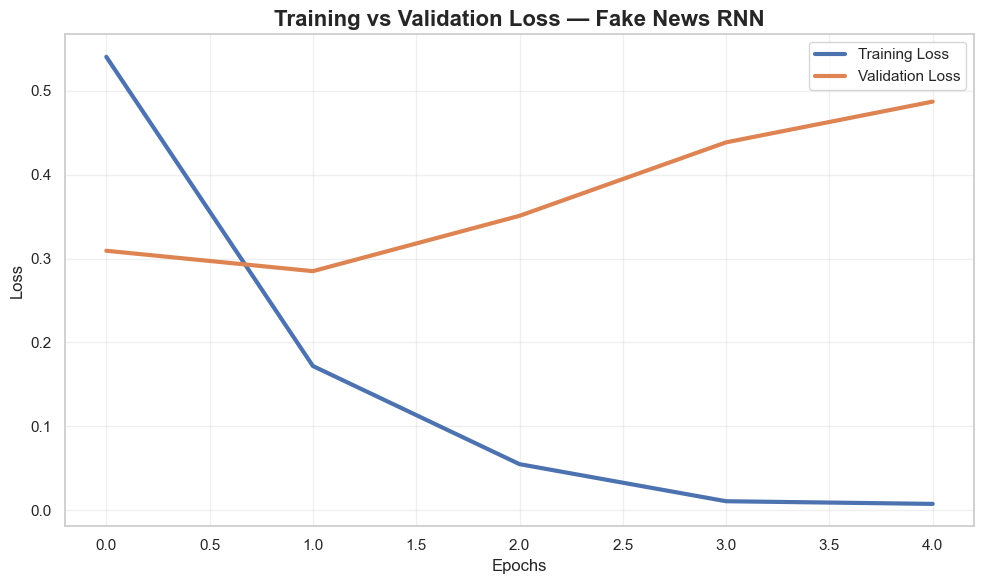

In [22]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

plt.plot(history.history['loss'],
         label='Training Loss',
         linewidth=3)

plt.plot(history.history['val_loss'],
         label='Validation Loss',
         linewidth=3)

plt.title(
    "Training vs Validation Loss — Fake News RNN",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()